In [1]:
!pip install nltk spacy wordcloud textblob scikit-learn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
!pip install wordcloud textblob

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import nltk
import spacy

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

!python -m spacy download en_core_web_sm

[nltk_data] Downloading package punkt to C:\Users\HP
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\HP
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\HP
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\HP
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\Users\HP
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



✘ No package installer found
spaCy requires either pip or uv to download models. Please install one of them
and try again.



In [5]:
import pandas as pd
import numpy as np
import re

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

# Spacy model - optional for NER
nlp = None
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
except:
    print("Note: Spacy model not available - NER analysis will be skipped")

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

Note: Spacy model not available - NER analysis will be skipped


 # Exploring  Text Data

In [7]:
print(df["Student Feedback"].head(10))

0    Assignments were manageable but could include ...
1    The course was generally good but some topics ...
2    I would not recommend this course without impr...
3    The lecturer moved too quickly through difficu...
4    The lecturer moved too quickly through difficu...
5    Assignments were confusing and lacked clear in...
6      Overall the learning experience was acceptable.
7      Overall the learning experience was acceptable.
8    The presentations were useful but could be mor...
9    Assignments were manageable but could include ...
Name: Student Feedback, dtype: object


In [6]:
# Load the CSV data
df = pd.read_csv("../data/student_feedback.csv")

# Text Cleaning

In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+"," ",text)
    text = re.sub(r"[^a-zA-Z ]"," ",text)
    text = re.sub(r"\s+"," ",text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

In [17]:
df["Clean Feedback"] = df["Student Feedback"].apply(clean_text)

df[["Student Feedback","Clean Feedback"]].head()

,Student Feedback,Clean Feedback
0,Assignments were manageable but could include ...,assignment manageable could include practical ...
1,The course was generally good but some topics ...,course generally good topic needed explanation
2,I would not recommend this course without impr...,would recommend course without improvement
3,The lecturer moved too quickly through difficu...,lecturer moved quickly difficult topic
4,The lecturer moved too quickly through difficu...,lecturer moved quickly difficult topic


# Feedback Length Analysis

In [18]:
df["Character Count"] = df["Student Feedback"].str.len()

df["Word Count"] = (
    df["Student Feedback"]
      .str.split()
      .str.len()
)

# Most Frequent Words

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["Clean Feedback"])

word_counts = (
    pd.DataFrame(
        X.toarray(),
        columns=vectorizer.get_feature_names_out()
    )
)

top_words = word_counts.sum().sort_values(ascending=False)

top_words

course          319
assignment      244
practical       240
topic           227
presentation    225
needed          218
difficult       209
teaching        146
pace            142
fast            142
learning        142
satisfactory    142
acceptable      136
experience      136
overall         136
include         133
work            133
manageable      133
interactive     126
useful          126
dtype: int64

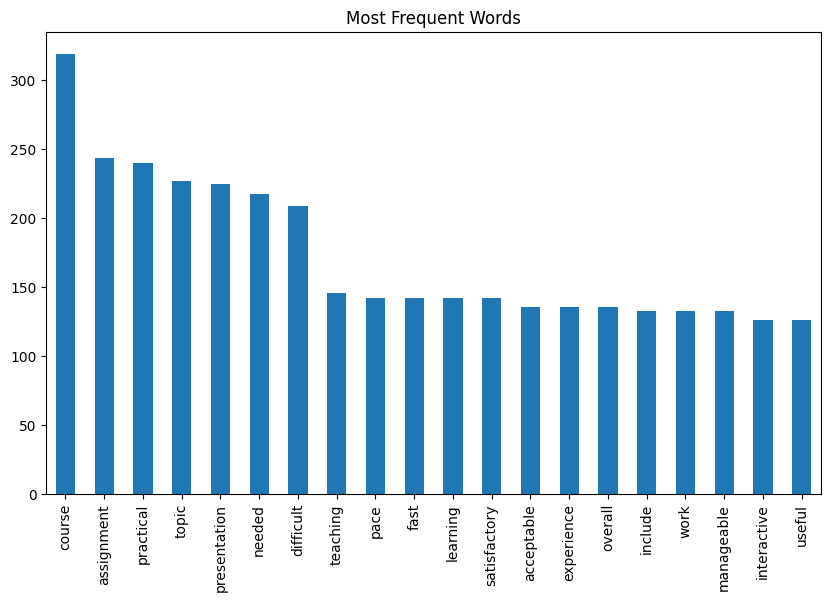

In [20]:
plt.figure(figsize=(10,6))

top_words.plot(kind="bar")

plt.title("Most Frequent Words")

plt.show()

# Word Cloud

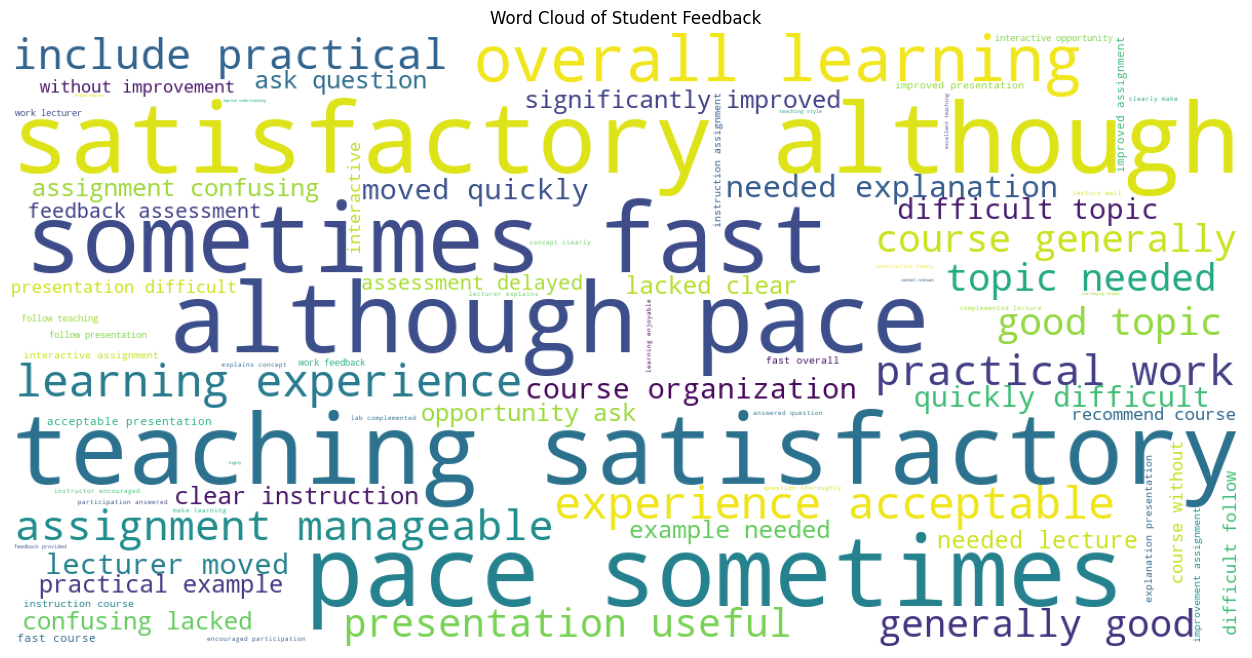

In [21]:
text = " ".join(df["Clean Feedback"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Student Feedback")

plt.show()

# Sentiment Analysis (TextBlob)

In [22]:
def sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0.2:
        return "Positive"

    elif polarity < -0.2:
        return "Negative"

    return "Neutral"

In [23]:
df["Sentiment"] = (
    df["Student Feedback"]
      .apply(sentiment)
)

df["Sentiment"].value_counts()

Sentiment
Neutral     802
Positive    599
Negative     99
Name: count, dtype: int64

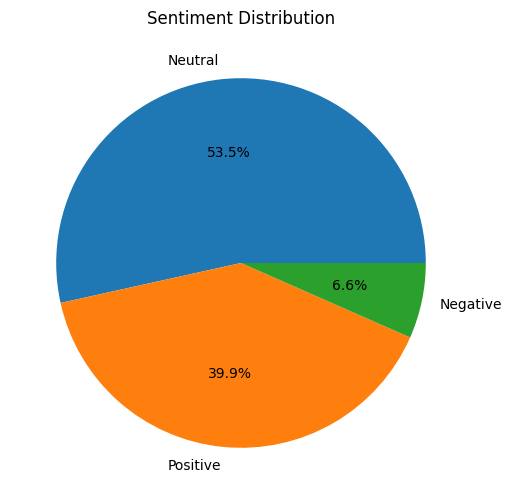

In [24]:
plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Sentiment Distribution")

plt.show()

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=500
)

tfidf_matrix = tfidf.fit_transform(df["Clean Feedback"])

print(tfidf_matrix.shape)

(1500, 76)


# Keyword Extraction

In [26]:
feature_names = tfidf.get_feature_names_out()

importance = (
    tfidf_matrix.sum(axis=0)
      .A1
)

keywords = pd.DataFrame({

    "Keyword":feature_names,

    "Importance":importance

})

keywords = keywords.sort_values(
    "Importance",
    ascending=False
)

keywords.head(20)

,Keyword,Importance
14,could,127.391192
56,presentation,110.452601
15,course,105.914180
17,difficult,96.532878
55,practical,94.902054
48,needed,88.783408
5,assignment,88.698170
69,topic,85.712420
39,interactive,70.688065
71,useful,70.688065


In [27]:
# Named Entity Recognition (if spacy available)
if nlp is not None:
    sample = df["Student Feedback"].iloc[0]
    doc = nlp(sample)
    print("Named Entities in first feedback:")
    for ent in doc.ents:
        print(f"{ent.text} ({ent.label_})")
else:
    print("Spacy model not available - skipping Named Entity Recognition")

Spacy model not available - skipping Named Entity Recognition


In [28]:
df.to_csv(
    "student_feedback_nlp.csv",
    index=False
)